# Step 1: Import Libraries and Load CIFAR-10 Dataset

In [1]:
!pip uninstall -y sympy
!pip install sympy==1.13.1

Found existing installation: sympy 1.14.0
Uninstalling sympy-1.14.0:
  Successfully uninstalled sympy-1.14.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.2/6.2 MB 51.4 MB/s eta 0:00:0000:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.10.0+cu128 requires sympy>=1.13.3, but you have sympy 1.13.1 which is incompatible.


In [2]:
# =========================================================
# Step 1: Import Required Libraries and Load CIFAR-10 Dataset
# =========================================================

import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# ---------------------------------------------------------
# Define image preprocessing transformations
#
# 1. Convert images to PyTorch tensors
# 2. Normalize pixel values to improve training stability
#
# CIFAR-10 images are RGB images of size 32x32
# ---------------------------------------------------------

transform = transforms.Compose([
    transforms.ToTensor(),

    # Normalize RGB channels
    # (mean = 0.5, std = 0.5 for each channel)
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

# ---------------------------------------------------------
# Load CIFAR-10 Training Dataset
#
# train=True → loads training split (50,000 images)
# download=True → downloads dataset if not already present
# ---------------------------------------------------------

train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

# ---------------------------------------------------------
# Create Training DataLoader
#
# batch_size → number of images per batch
# shuffle=True → randomize data for better learning
# num_workers=2 → parallel loading for faster training
#
# NOTE:
# Using batch_size=64 instead of 4 for faster training
# and better GPU utilization in Kaggle notebooks
# ---------------------------------------------------------

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2
)

# ---------------------------------------------------------
# Load CIFAR-10 Test Dataset
#
# train=False → loads test split (10,000 images)
# ---------------------------------------------------------

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

# ---------------------------------------------------------
# Create Test DataLoader
#
# shuffle=False → preserve order during evaluation
# ---------------------------------------------------------

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2
)

# ---------------------------------------------------------
# CIFAR-10 Class Labels
# These are the 10 output classes for classification
# ---------------------------------------------------------

classes = (
    "plane", "car", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
)

# ---------------------------------------------------------
# Quick sanity check
# ---------------------------------------------------------

print("Training samples:", len(train_dataset))
print("Testing samples :", len(test_dataset))
print("Classes         :", classes)

100%|██████████| 170M/170M [00:02<00:00, 75.5MB/s] 


Training samples: 50000
Testing samples : 10000
Classes         : ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


# Step 2: Visualize Sample Images from the CIFAR-10 Dataset

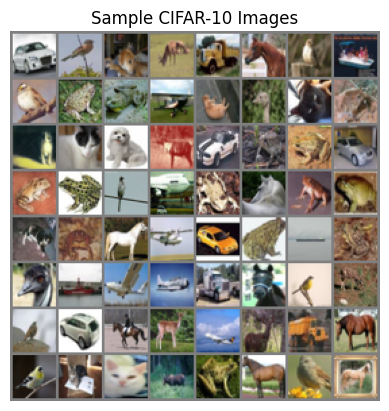

Labels:
car | bird | dog | deer | truck | horse | bird | ship | 

In [3]:
# =========================================================
# Step 2: Visualize Sample Images from CIFAR-10
# =========================================================

import matplotlib.pyplot as plt
import numpy as np
import torchvision

# ---------------------------------------------------------
# Function to display images
#
# Since we normalized the images earlier using:
# Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
#
# we need to reverse (unnormalize) that step before
# displaying them properly.
# ---------------------------------------------------------

def imshow(img):
    """
    Display an image using matplotlib.

    Parameters:
    img : torch.Tensor
        Image tensor in shape (C, H, W)
    """

    # Unnormalize the image
    img = img / 2 + 0.5

    # Convert tensor to NumPy array
    np_img = img.numpy()

    # Change shape from (C, H, W) → (H, W, C)
    plt.imshow(np.transpose(np_img, (1, 2, 0)))

    plt.title("Sample CIFAR-10 Images")
    plt.axis("off")
    plt.show()


# ---------------------------------------------------------
# Get a batch of random training images
# ---------------------------------------------------------

data_iterator = iter(train_loader)

# Fetch one batch
images, labels = next(data_iterator)

# ---------------------------------------------------------
# Display images in grid format
#
# torchvision.utils.make_grid() combines multiple images
# into one visual grid for easier viewing
# ---------------------------------------------------------

imshow(torchvision.utils.make_grid(images))

# ---------------------------------------------------------
# Print corresponding class labels
# ---------------------------------------------------------

print("Labels:")

for i in range(8):  # showing first 8 labels from batch
    print(f"{classes[labels[i]]}", end=" | ")

In [4]:
from collections import Counter

label_counts = Counter(train_dataset.targets)
print(label_counts)

Counter({6: 5000, 9: 5000, 4: 5000, 1: 5000, 2: 5000, 7: 5000, 8: 5000, 3: 5000, 5: 5000, 0: 5000})


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


# Step 3: Defining the Custom Prunable Linear Layer
# Step 4 : Building the Self-Pruning Neural Network


In [41]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        # Kaiming/Xavier-style initialization is better than randn * 0.01 for deep nets
        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.01)
        self.bias = nn.Parameter(torch.zeros(out_features))
        
        # FIX: Initialize to +2.0 (Sigmoid ≈ 0.88). 
        # Starting with high gate values allows the model to learn features 
        # before the L1 penalty starts pruning them. 
        self.gate_scores = nn.Parameter(torch.ones(out_features, in_features) * +2.0) ## change it back to 2

    def forward(self, x):
        gates = torch.sigmoid(self.gate_scores) # 
        pruned_weights = self.weight * gates # [cite: 79]
        return F.linear(x, pruned_weights, self.bias) # [cite: 80]

class PrunableConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, padding=0, stride=1):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(out_channels, in_channels, kernel_size, kernel_size) * 0.01)
        self.bias = nn.Parameter(torch.zeros(out_channels))
        # FIX: Initialize to +2.0 to ensure early training stability
        self.gate_scores = nn.Parameter(torch.ones(out_channels, in_channels, kernel_size, kernel_size) * +2.0)
        self.padding = padding
        self.stride = stride

    def forward(self, x):
        gates = torch.sigmoid(self.gate_scores)
        pruned_weights = self.weight * gates
        return F.conv2d(x, pruned_weights, self.bias, stride=self.stride, padding=self.padding)

class PrunableNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = PrunableConv2d(3, 32, 3, padding=1)
        self.conv2 = PrunableConv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        # 32x32 -> pool -> 16x16 -> pool -> 8x8
        self.fc1 = PrunableLinear(64 * 8 * 8, 512)
        self.bn1 = nn.BatchNorm1d(512)
        self.fc2 = PrunableLinear(512, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.fc2(x)
        return x

    def get_all_gates(self):
        gates = []
        for module in self.modules():
            if isinstance(module, (PrunableConv2d, PrunableLinear)):
                gates.append(torch.sigmoid(module.gate_scores))
        return gates

# Step 5: Visualize the Network Architecture

In [42]:
# =========================================================
# Step 5: Visualize the Network Architecture
# =========================================================

# Create model instance
model = PrunableNet()

# Print full model architecture
print(model)

PrunableNet(
  (conv1): PrunableConv2d()
  (conv2): PrunableConv2d()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): PrunableLinear()
  (bn1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): PrunableLinear()
)


In [36]:
# Count total trainable parameters

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total Trainable Parameters: {total_params:,}")

Total Trainable Parameters: 4,244,778


# Step 6: Define the Sparsity Loss (L1 Regularization on Gates)

In [57]:
def compute_sparsity_loss(model):
    """
    FIX: Compute the MEAN of gates, not the SUM.
    If you have 1 million gates, the sum is huge. 
    The mean is always between 0 and 1, making lambda_val easy to tune.
    """
    total_gate_sum = 0.0
    total_gate_count = 0
    
    for gates in model.get_all_gates():
        total_gate_sum += gates.sum()
        total_gate_count += gates.numel() # Count total parameters in this layer
        
    # Return average gate activity 
    return total_gate_sum / total_gate_count if total_gate_count > 0 else 0.0

In [58]:
model = PrunableNet()

loss = compute_sparsity_loss(model)

print("Initial Sparsity Loss:", loss.item())

Initial Sparsity Loss: 0.8807973265647888


# Step 7: Training the Model

In [59]:
# Check if GPU is available, otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Move the entire model to the device
model = PrunableNet().to(device) 

# Now define the optimizer AFTER moving the model
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [60]:
# =========================================================
# Step 6: Optimized Optimizer & Hyperparameters
# =========================================================

# Strict lambda as per your requirement
lambda_val = 0.001 # [cite: 92, 104]
epochs = 10

# Separate gate parameters from standard weights/biases [cite: 74, 98]
gate_params = [p for n, p in model.named_parameters() if "gate_scores" in n]
other_params = [p for n, p in model.named_parameters() if "gate_scores" not in n]

# Give gates a much higher LR (0.1) to overcome the "flat" Sigmoid region [cite: 25, 131]
optimizer = torch.optim.Adam([
    {'params': other_params, 'lr': 1e-3},
    {'params': gate_params, 'lr': 1e-1} 
])

criterion = nn.CrossEntropyLoss() # [cite: 84]

model.train()
for epoch in range(epochs):
    total_loss_epoch = 0.0
    
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()

        # Forward pass through prunable layers [cite: 75, 80]
        outputs = model(inputs)
        cls_loss = criterion(outputs, targets)
        
        # Calculate Sparsity Loss (Layer-wise Mean Sum) [cite: 87, 89]
        sparsity_loss = compute_sparsity_loss(model) 

        # Total Loss = Accuracy + Pruning Pressure [cite: 87]
        total_loss = cls_loss + (lambda_val * sparsity_loss) 

        total_loss.backward() # [cite: 82]
        
        # Gradient Clipping to prevent "abnormal spikes" in gates [cite: 41, 124]
        torch.nn.utils.clip_grad_norm_(gate_params, max_norm=1.0)
        
        optimizer.step() # [cite: 98]
        total_loss_epoch += total_loss.item()

    # --- Metrics for your Markdown Report --- [cite: 113]
    
    # Flatten all gates to calculate statistics [cite: 88, 101]
    all_gates = torch.cat([g.flatten() for g in model.get_all_gates()])
    gate_mean = all_gates.mean().item()
    
    # Calculate Sparsity % based on the 1e-2 threshold [cite: 101]
    sparsity_pct = (all_gates < 0.01).float().mean().item() * 100

    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Loss: {total_loss_epoch/len(train_loader):.4f} | "
          f"Gate Mean: {gate_mean:.4f} | "
          f"Sparsity: {sparsity_pct:.2f}%")

Epoch [1/10] | Loss: 1.1781 | Gate Mean: 0.7060 | Sparsity: 0.00%
Epoch [2/10] | Loss: 0.7908 | Gate Mean: 0.6260 | Sparsity: 0.18%
Epoch [3/10] | Loss: 0.5935 | Gate Mean: 0.5642 | Sparsity: 1.60%
Epoch [4/10] | Loss: 0.4327 | Gate Mean: 0.5108 | Sparsity: 5.81%
Epoch [5/10] | Loss: 0.2967 | Gate Mean: 0.4674 | Sparsity: 11.89%
Epoch [6/10] | Loss: 0.1914 | Gate Mean: 0.4330 | Sparsity: 17.88%
Epoch [7/10] | Loss: 0.1284 | Gate Mean: 0.4053 | Sparsity: 23.08%
Epoch [8/10] | Loss: 0.0887 | Gate Mean: 0.3836 | Sparsity: 27.17%
Epoch [9/10] | Loss: 0.0661 | Gate Mean: 0.3665 | Sparsity: 30.48%
Epoch [10/10] | Loss: 0.0530 | Gate Mean: 0.3532 | Sparsity: 33.13%


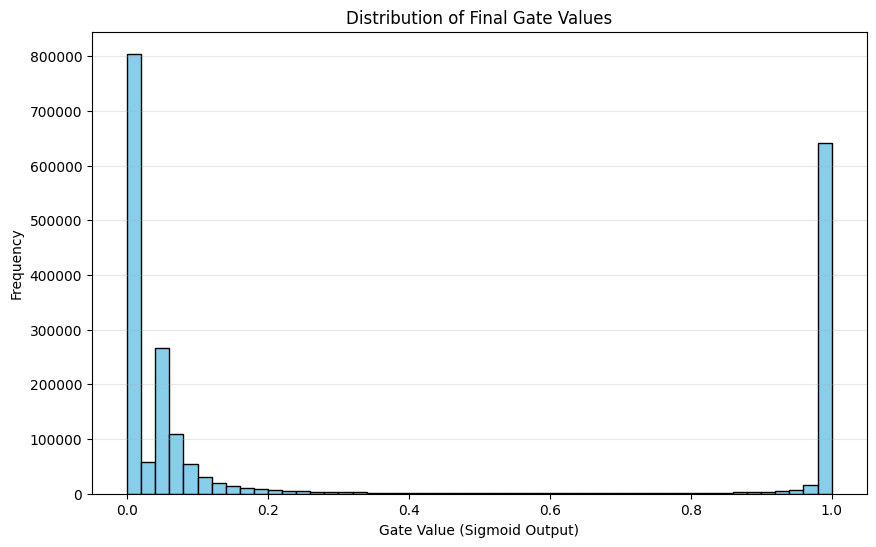

In [61]:
import matplotlib.pyplot as plt

def plot_gate_distribution(model):
    all_gates = torch.cat([g.flatten() for g in model.get_all_gates()]).detach().cpu().numpy()
    
    plt.figure(figsize=(10, 6))
    plt.hist(all_gates, bins=50, color='skyblue', edgecolor='black')
    plt.title("Distribution of Final Gate Values")
    plt.xlabel("Gate Value (Sigmoid Output)")
    plt.ylabel("Frequency")
    plt.grid(axis='y', alpha=0.3)
    plt.show()

# Run this after your training finishes
plot_gate_distribution(model)

# Step 8: Evaluate Model Accuracy and Sparsity

In [62]:
# =========================================================
# Step 8: Evaluate Accuracy and Sparsity
# =========================================================


def compute_sparsity(model, threshold=1e-2):
    """
    Compute percentage of pruned connections

    A connection is considered pruned if:

        gate < threshold

    Default threshold:
        0.01
    """

    total_gates = 0
    pruned_gates = 0

    # Loop through all PrunableLinear layers
    for module in model.modules():

        if isinstance(module, PrunableLinear):

            # Convert gate scores to actual gate values
            gates = torch.sigmoid(module.gate_scores)

            # Total number of gates
            total_gates += gates.numel()

            # Count gates smaller than threshold
            pruned_gates += (gates < threshold).sum().item()

    sparsity_percentage = (
        pruned_gates / total_gates
    ) * 100

    return sparsity_percentage


def evaluate(model, test_loader, device):
    """
    Compute classification accuracy on test dataset
    """

    # Set model to evaluation mode
    model.eval()

    correct = 0
    total = 0

    # Disable gradient computation
    with torch.no_grad():

        for inputs, targets in test_loader:

            # Move data to device
            inputs = inputs.to(device)
            targets = targets.to(device)

            # Forward pass
            outputs = model(inputs)

            # Get predicted class
            _, predicted = torch.max(outputs, 1)

            total += targets.size(0)
            correct += (
                predicted == targets
            ).sum().item()

    accuracy = (correct / total) * 100

    return accuracy


# ---------------------------------------------------------
# Run evaluation
# ---------------------------------------------------------

accuracy = evaluate(model, test_loader, device)
sparsity = compute_sparsity(model)

print(f"Test Accuracy : {accuracy:.2f}%")
print(f"Sparsity      : {sparsity:.2f}%")

Test Accuracy : 73.07%
Sparsity      : 33.08%


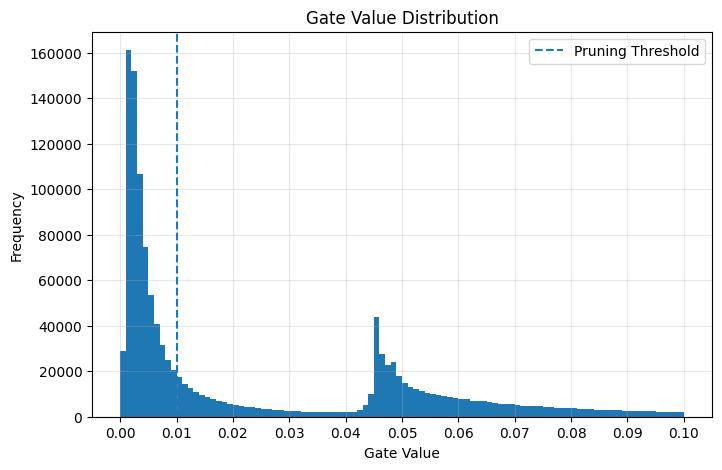

In [63]:
# =========================================================
# Step 12: Gate Value Distribution Histogram
# =========================================================

import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------
# Collect all gate values from trained model
# ---------------------------------------------------------

all_gates = []

for module in model.modules():
    if isinstance(module, PrunableLinear):

        # Convert gate scores to gate values
        gates = torch.sigmoid(
            module.gate_scores
        ).detach().cpu().numpy()

        all_gates.extend(
            gates.flatten()
        )

all_gates = np.array(all_gates)

# ---------------------------------------------------------
# Plot histogram
# ---------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.hist(
    all_gates,
    bins=100,
    range=(0, 0.1)   # zoom into important region
)

# Better x-axis ticks
ticks = np.arange(0, 0.11, 0.01)
plt.xticks(ticks)

# Optional pruning threshold line
plt.axvline(
    x=0.01,
    linestyle='--',
    label="Pruning Threshold"
)

plt.title("Gate Value Distribution")
plt.xlabel("Gate Value")
plt.ylabel("Frequency")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

# Step 9: Compare Model Performance for Multiple Lambda Values

In [65]:
# =========================================================
# Step 9: Compare Multiple Lambda Values
# (Optimized for Gradient Flow & Decoupled LR)
# =========================================================

import torch.optim as optim

# Lambda values for comparison: Low, Medium, High [cite: 104]
lambda_values = [1e-4, 1e-3, 1e-2]
epochs = 10
results = []

for lambda_val in lambda_values:
    print(f"\n{'='*20} Training with lambda = {lambda_val} {'='*20}")

    # 1. Fresh model initialization for each experiment [cite: 40]
    model = PrunableNet().to(device)

    # 2. Decouple parameters: High LR for gates, standard for weights [cite: 25, 131]
    gate_params = [p for n, p in model.named_parameters() if "gate_scores" in n]
    other_params = [p for n, p in model.named_parameters() if "gate_scores" not in n]

    optimizer = optim.Adam([
        {'params': other_params, 'lr': 1e-3}, # [cite: 98]
        {'params': gate_params, 'lr': 1e-1}  # High LR to move scores through flat Sigmoid regions
    ])

    model.train()

    # 3. Training Loop
    for epoch in range(epochs):
        total_loss_epoch = 0.0

        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()

            # Forward pass [cite: 75, 80]
            outputs = model(inputs)
            cls_loss = criterion(outputs, targets) # [cite: 84]
            
            # Compute sparsity penalty [cite: 87, 89]
            sparsity_loss = compute_sparsity_loss(model)

            # Total Loss formulation [cite: 87]
            total_loss = cls_loss + (lambda_val * sparsity_loss)

            total_loss.backward() # [cite: 82]
            
            # Gradient clipping to stabilize gate score updates [cite: 41, 124]
            torch.nn.utils.clip_grad_norm_(gate_params, max_norm=1.0)
            
            optimizer.step() # [cite: 98]
            total_loss_epoch += total_loss.item()

        # Log progress for monitoring the trade-off [cite: 123]
        all_gates = torch.cat([g.flatten() for g in model.get_all_gates()])
        current_sparsity = (all_gates < 0.01).float().mean().item() * 100
        print(f"Epoch [{epoch + 1}/{epochs}] | Loss: {total_loss_epoch/len(train_loader):.4f} | Sparsity: {current_sparsity:.2f}%")

    # 4. Final Evaluation [cite: 99]
    # Assuming evaluate() returns test accuracy %
    accuracy = evaluate(model, test_loader, device) 
    final_sparsity = (all_gates < 0.01).float().mean().item() * 100 # 

    print(f"\n>>> RESULT FOR LAMBDA {lambda_val}: Accuracy: {accuracy:.2f}% | Sparsity: {final_sparsity:.2f}%")
    results.append((lambda_val, accuracy, final_sparsity))

# 5. Display Summary Table for Report 
print("\n" + "="*40)
print(f"{'Lambda':<10} | {'Test Accuracy':<15} | {'Sparsity (%)':<15}")
print("-" * 40)
for l, acc, sp in results:
    print(f"{l:<10} | {acc:<15.2f} | {sp:<15.2f}")


==================== Training with lambda = 0.0001 ====================
Epoch [1/10] | Loss: 1.1683 | Sparsity: 0.00%
Epoch [2/10] | Loss: 0.7797 | Sparsity: 0.10%
Epoch [3/10] | Loss: 0.5799 | Sparsity: 1.26%
Epoch [4/10] | Loss: 0.4112 | Sparsity: 5.21%
Epoch [5/10] | Loss: 0.2746 | Sparsity: 11.40%
Epoch [6/10] | Loss: 0.1745 | Sparsity: 17.84%
Epoch [7/10] | Loss: 0.1138 | Sparsity: 23.59%
Epoch [8/10] | Loss: 0.0761 | Sparsity: 28.02%
Epoch [9/10] | Loss: 0.0583 | Sparsity: 31.96%
Epoch [10/10] | Loss: 0.0492 | Sparsity: 35.25%

>>> RESULT FOR LAMBDA 0.0001: Accuracy: 73.26% | Sparsity: 35.25%

==================== Training with lambda = 0.001 ====================
Epoch [1/10] | Loss: 1.1538 | Sparsity: 0.00%
Epoch [2/10] | Loss: 0.7758 | Sparsity: 0.12%
Epoch [3/10] | Loss: 0.5799 | Sparsity: 1.54%
Epoch [4/10] | Loss: 0.4064 | Sparsity: 5.91%
Epoch [5/10] | Loss: 0.2712 | Sparsity: 12.59%
Epoch [6/10] | Loss: 0.1735 | Sparsity: 19.34%
Epoch [7/10] | Loss: 0.1103 | Sparsity: 24.

# Step 10 : Hyperparameter Search and Plotting


LR=0.001 | GateLR=0.1 | Init=2.0 | λ=0.0001 | Epochs=5
Epoch [1/5] | Loss: 1.16
Epoch [2/5] | Loss: 0.77
Epoch [3/5] | Loss: 0.57
Epoch [4/5] | Loss: 0.41
Epoch [5/5] | Loss: 0.27

Final Accuracy : 75.11% | Final Sparsity : 11.78%


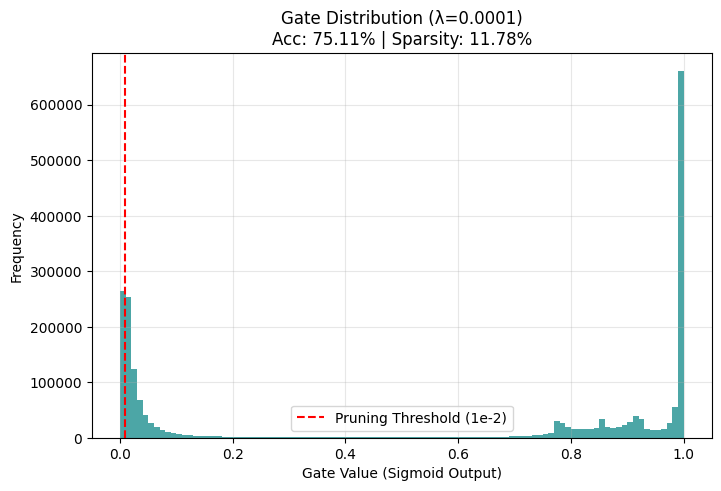


LR=0.001 | GateLR=0.1 | Init=2.0 | λ=0.0001 | Epochs=10
Epoch [1/10] | Loss: 1.17
Epoch [2/10] | Loss: 0.78
Epoch [3/10] | Loss: 0.58
Epoch [4/10] | Loss: 0.42
Epoch [5/10] | Loss: 0.28
Epoch [6/10] | Loss: 0.18
Epoch [7/10] | Loss: 0.12
Epoch [8/10] | Loss: 0.08
Epoch [9/10] | Loss: 0.06
Epoch [10/10] | Loss: 0.05

Final Accuracy : 74.06% | Final Sparsity : 34.71%


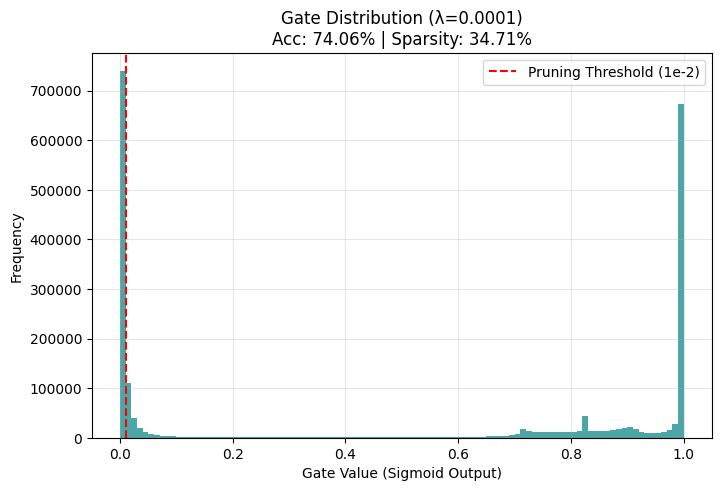


LR=0.001 | GateLR=0.1 | Init=2.0 | λ=0.001 | Epochs=5
Epoch [1/5] | Loss: 1.16
Epoch [2/5] | Loss: 0.77
Epoch [3/5] | Loss: 0.57
Epoch [4/5] | Loss: 0.40
Epoch [5/5] | Loss: 0.27

Final Accuracy : 73.89% | Final Sparsity : 11.44%


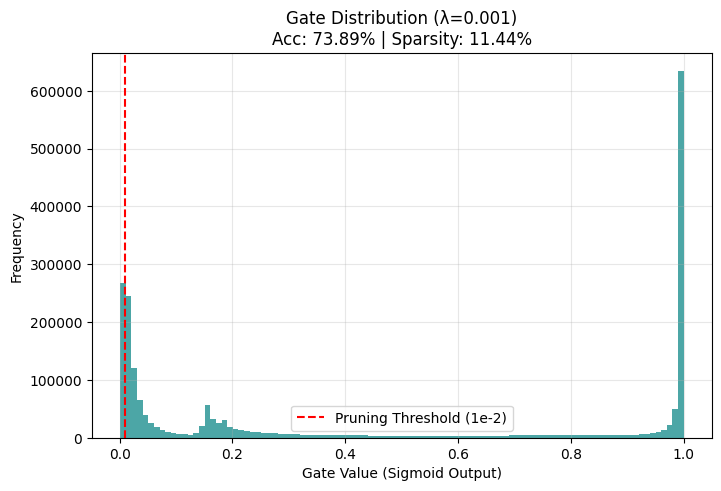


LR=0.001 | GateLR=0.1 | Init=2.0 | λ=0.001 | Epochs=10
Epoch [1/10] | Loss: 1.16
Epoch [2/10] | Loss: 0.78
Epoch [3/10] | Loss: 0.58
Epoch [4/10] | Loss: 0.41
Epoch [5/10] | Loss: 0.28
Epoch [6/10] | Loss: 0.18
Epoch [7/10] | Loss: 0.11
Epoch [8/10] | Loss: 0.08
Epoch [9/10] | Loss: 0.06
Epoch [10/10] | Loss: 0.05

Final Accuracy : 74.28% | Final Sparsity : 35.68%


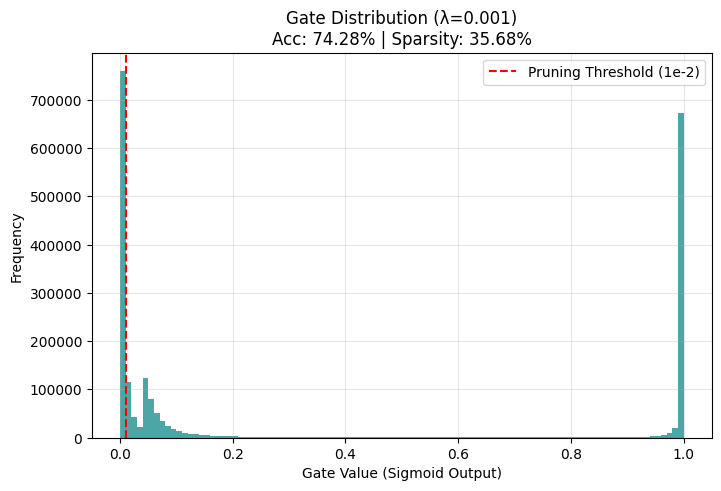


LR=0.001 | GateLR=0.1 | Init=2.0 | λ=0.01 | Epochs=5
Epoch [1/5] | Loss: 1.17
Epoch [2/5] | Loss: 0.78
Epoch [3/5] | Loss: 0.58
Epoch [4/5] | Loss: 0.41
Epoch [5/5] | Loss: 0.27

Final Accuracy : 74.43% | Final Sparsity : 26.24%


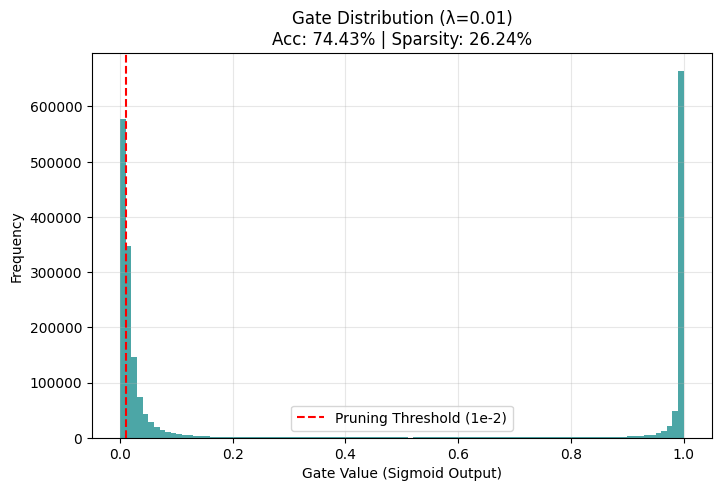


LR=0.001 | GateLR=0.1 | Init=2.0 | λ=0.01 | Epochs=10
Epoch [1/10] | Loss: 1.16
Epoch [2/10] | Loss: 0.78
Epoch [3/10] | Loss: 0.57
Epoch [4/10] | Loss: 0.41
Epoch [5/10] | Loss: 0.27
Epoch [6/10] | Loss: 0.18
Epoch [7/10] | Loss: 0.12
Epoch [8/10] | Loss: 0.08
Epoch [9/10] | Loss: 0.06
Epoch [10/10] | Loss: 0.05

Final Accuracy : 74.03% | Final Sparsity : 58.03%


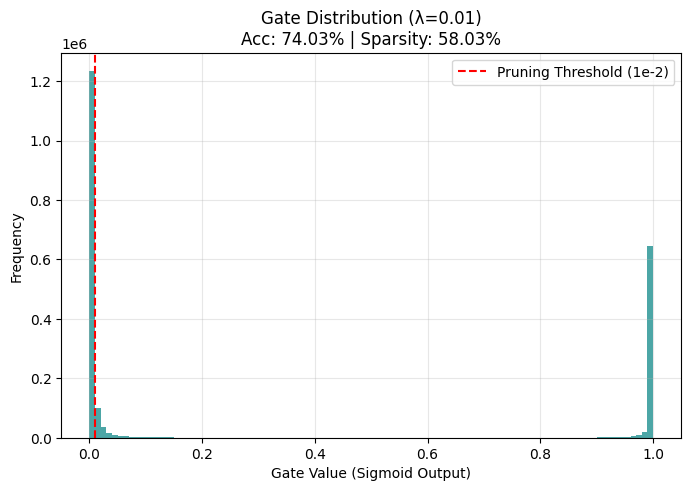


LR=0.001 | GateLR=0.01 | Init=2.0 | λ=0.0001 | Epochs=5
Epoch [1/5] | Loss: 1.17
Epoch [2/5] | Loss: 0.80
Epoch [3/5] | Loss: 0.60
Epoch [4/5] | Loss: 0.44
Epoch [5/5] | Loss: 0.29

Final Accuracy : 74.13% | Final Sparsity : 0.00%


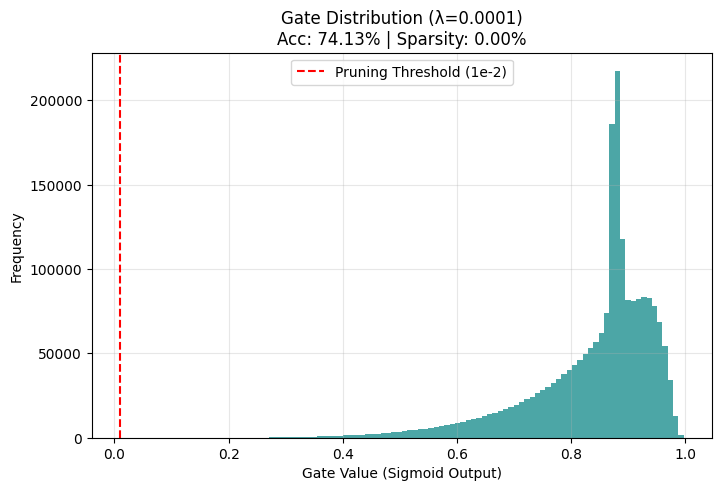


LR=0.001 | GateLR=0.01 | Init=2.0 | λ=0.0001 | Epochs=10
Epoch [1/10] | Loss: 1.17
Epoch [2/10] | Loss: 0.79
Epoch [3/10] | Loss: 0.59
Epoch [4/10] | Loss: 0.41
Epoch [5/10] | Loss: 0.27
Epoch [6/10] | Loss: 0.17
Epoch [7/10] | Loss: 0.12
Epoch [8/10] | Loss: 0.08
Epoch [9/10] | Loss: 0.06
Epoch [10/10] | Loss: 0.06

Final Accuracy : 75.21% | Final Sparsity : 0.00%


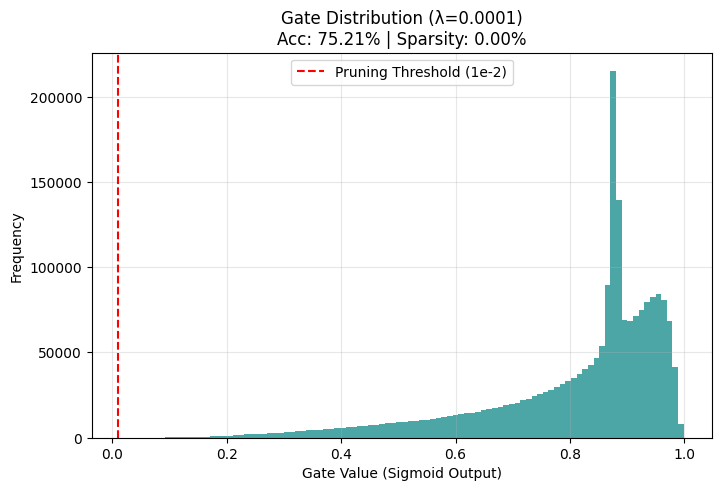


LR=0.001 | GateLR=0.01 | Init=2.0 | λ=0.001 | Epochs=5
Epoch [1/5] | Loss: 1.16
Epoch [2/5] | Loss: 0.79
Epoch [3/5] | Loss: 0.59
Epoch [4/5] | Loss: 0.43
Epoch [5/5] | Loss: 0.28

Final Accuracy : 73.85% | Final Sparsity : 0.00%


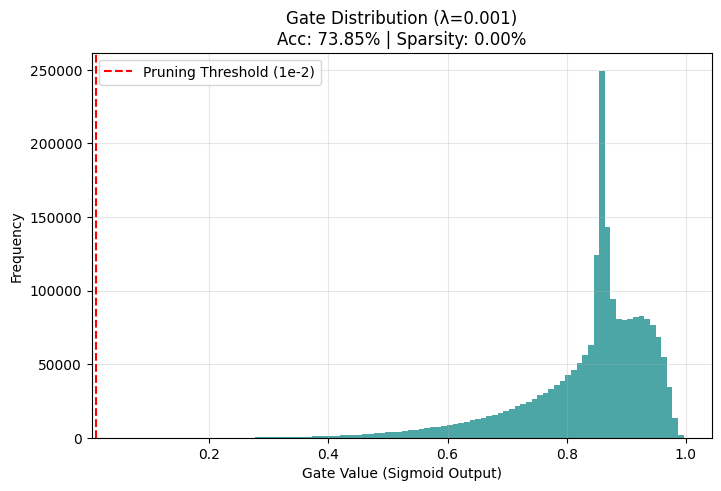


LR=0.001 | GateLR=0.01 | Init=2.0 | λ=0.001 | Epochs=10
Epoch [1/10] | Loss: 1.17
Epoch [2/10] | Loss: 0.80
Epoch [3/10] | Loss: 0.60
Epoch [4/10] | Loss: 0.43
Epoch [5/10] | Loss: 0.29
Epoch [6/10] | Loss: 0.18
Epoch [7/10] | Loss: 0.11
Epoch [8/10] | Loss: 0.09
Epoch [9/10] | Loss: 0.06
Epoch [10/10] | Loss: 0.06

Final Accuracy : 74.76% | Final Sparsity : 0.00%


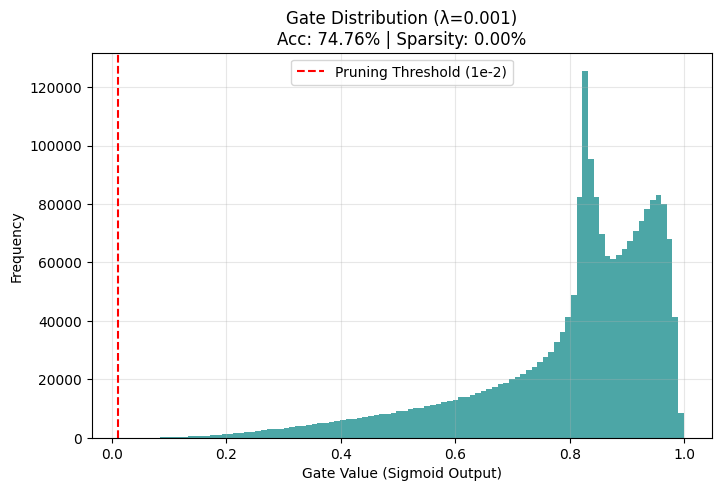


LR=0.001 | GateLR=0.01 | Init=2.0 | λ=0.01 | Epochs=5
Epoch [1/5] | Loss: 1.18
Epoch [2/5] | Loss: 0.81
Epoch [3/5] | Loss: 0.61
Epoch [4/5] | Loss: 0.44
Epoch [5/5] | Loss: 0.29

Final Accuracy : 74.86% | Final Sparsity : 0.00%


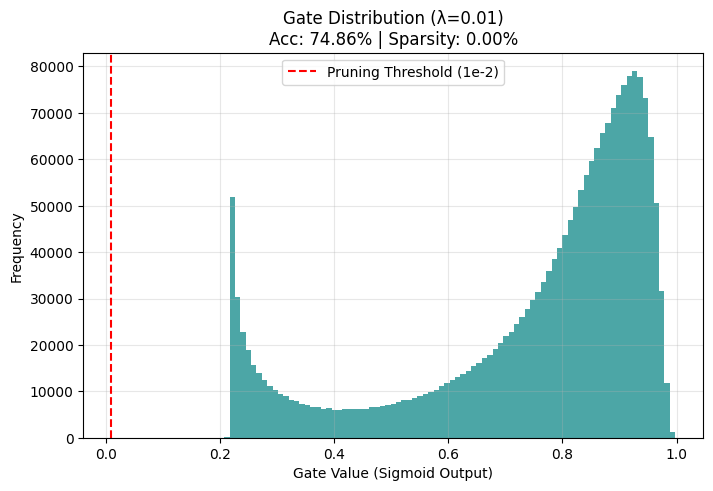


LR=0.001 | GateLR=0.01 | Init=2.0 | λ=0.01 | Epochs=10
Epoch [1/10] | Loss: 1.17
Epoch [2/10] | Loss: 0.79
Epoch [3/10] | Loss: 0.60
Epoch [4/10] | Loss: 0.42
Epoch [5/10] | Loss: 0.27
Epoch [6/10] | Loss: 0.18
Epoch [7/10] | Loss: 0.11
Epoch [8/10] | Loss: 0.08
Epoch [9/10] | Loss: 0.07
Epoch [10/10] | Loss: 0.06

Final Accuracy : 74.62% | Final Sparsity : 0.00%


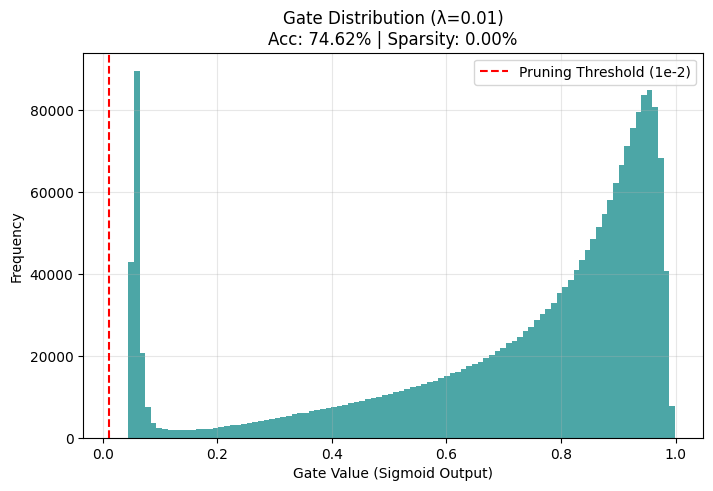


LR=0.001 | GateLR=0.001 | Init=2.0 | λ=0.0001 | Epochs=5
Epoch [1/5] | Loss: 1.16
Epoch [2/5] | Loss: 0.80
Epoch [3/5] | Loss: 0.60
Epoch [4/5] | Loss: 0.44
Epoch [5/5] | Loss: 0.30

Final Accuracy : 73.53% | Final Sparsity : 0.00%


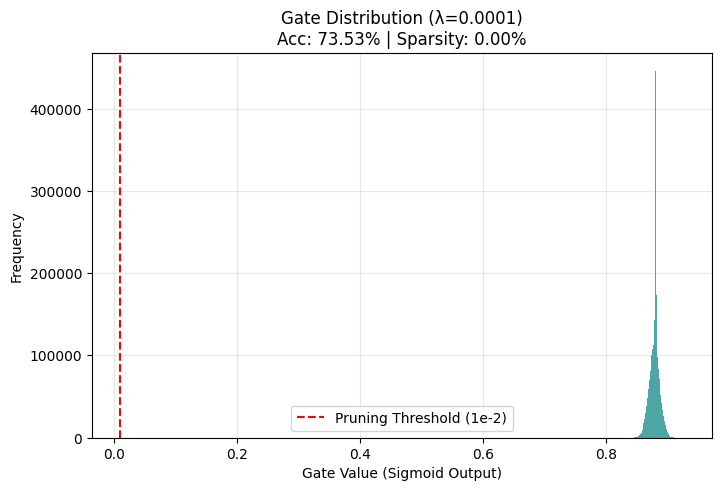


LR=0.001 | GateLR=0.001 | Init=2.0 | λ=0.0001 | Epochs=10
Epoch [1/10] | Loss: 1.18
Epoch [2/10] | Loss: 0.81
Epoch [3/10] | Loss: 0.61
Epoch [4/10] | Loss: 0.45
Epoch [5/10] | Loss: 0.31
Epoch [6/10] | Loss: 0.20
Epoch [7/10] | Loss: 0.13
Epoch [8/10] | Loss: 0.10
Epoch [9/10] | Loss: 0.08
Epoch [10/10] | Loss: 0.06

Final Accuracy : 74.36% | Final Sparsity : 0.00%


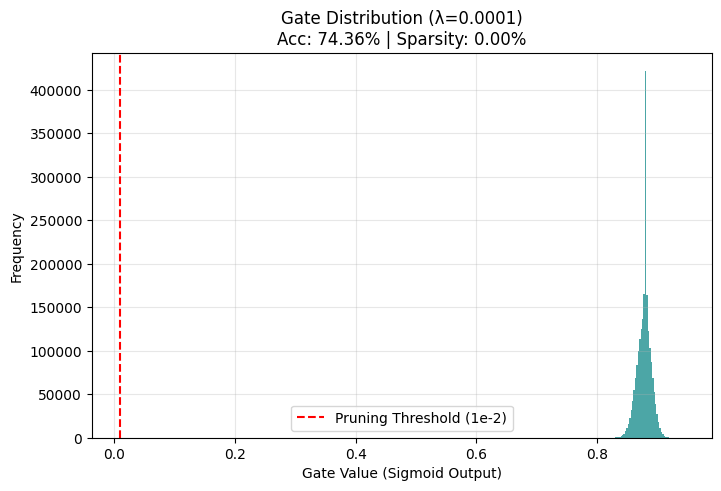


LR=0.001 | GateLR=0.001 | Init=2.0 | λ=0.001 | Epochs=5
Epoch [1/5] | Loss: 1.17
Epoch [2/5] | Loss: 0.79
Epoch [3/5] | Loss: 0.60
Epoch [4/5] | Loss: 0.43
Epoch [5/5] | Loss: 0.30

Final Accuracy : 74.27% | Final Sparsity : 0.00%


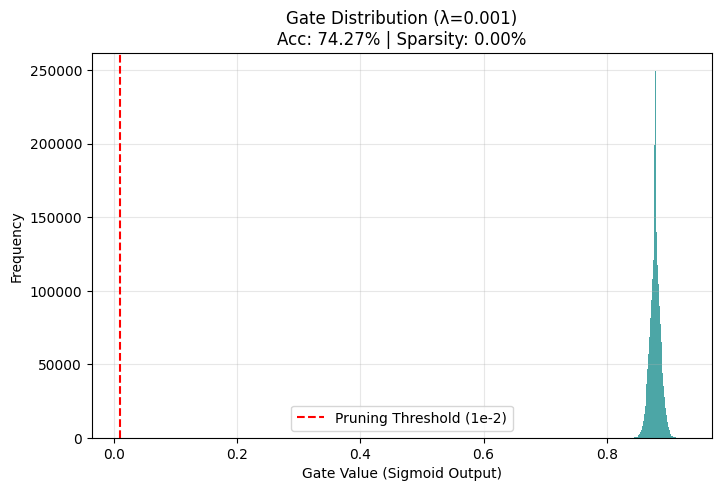


LR=0.001 | GateLR=0.001 | Init=2.0 | λ=0.001 | Epochs=10
Epoch [1/10] | Loss: 1.17
Epoch [2/10] | Loss: 0.80
Epoch [3/10] | Loss: 0.61
Epoch [4/10] | Loss: 0.44
Epoch [5/10] | Loss: 0.30
Epoch [6/10] | Loss: 0.20
Epoch [7/10] | Loss: 0.13
Epoch [8/10] | Loss: 0.10
Epoch [9/10] | Loss: 0.08
Epoch [10/10] | Loss: 0.07

Final Accuracy : 74.09% | Final Sparsity : 0.00%


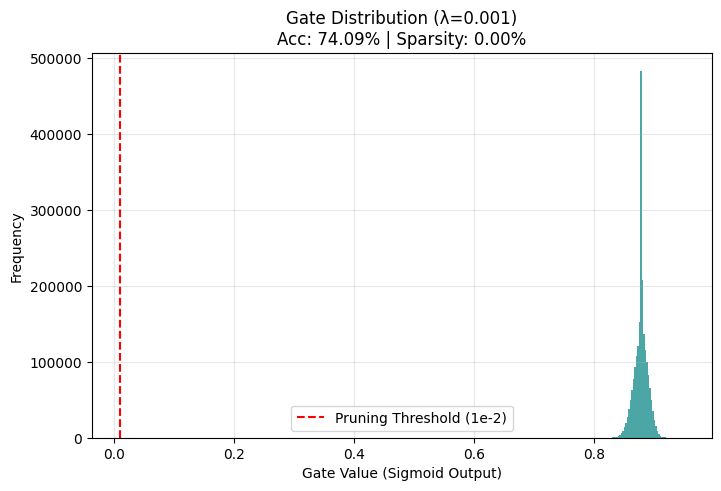


LR=0.001 | GateLR=0.001 | Init=2.0 | λ=0.01 | Epochs=5
Epoch [1/5] | Loss: 1.18
Epoch [2/5] | Loss: 0.80
Epoch [3/5] | Loss: 0.61
Epoch [4/5] | Loss: 0.45
Epoch [5/5] | Loss: 0.31

Final Accuracy : 74.15% | Final Sparsity : 0.00%


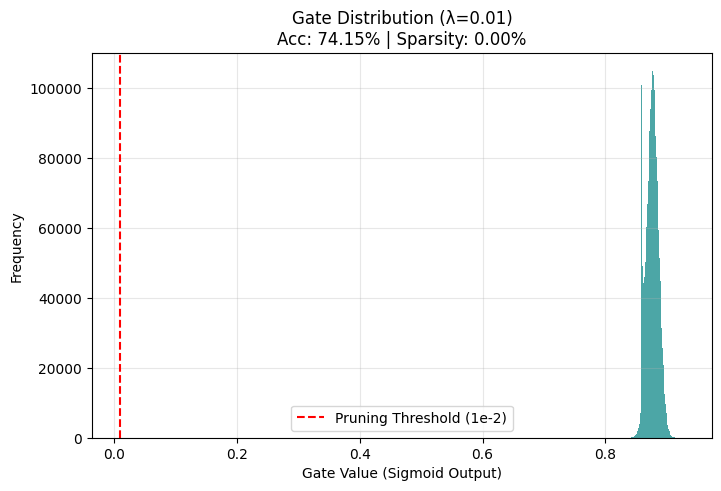


LR=0.001 | GateLR=0.001 | Init=2.0 | λ=0.01 | Epochs=10
Epoch [1/10] | Loss: 1.19
Epoch [2/10] | Loss: 0.82
Epoch [3/10] | Loss: 0.63
Epoch [4/10] | Loss: 0.47
Epoch [5/10] | Loss: 0.32
Epoch [6/10] | Loss: 0.21
Epoch [7/10] | Loss: 0.15
Epoch [8/10] | Loss: 0.10
Epoch [9/10] | Loss: 0.08
Epoch [10/10] | Loss: 0.08

Final Accuracy : 73.51% | Final Sparsity : 0.00%


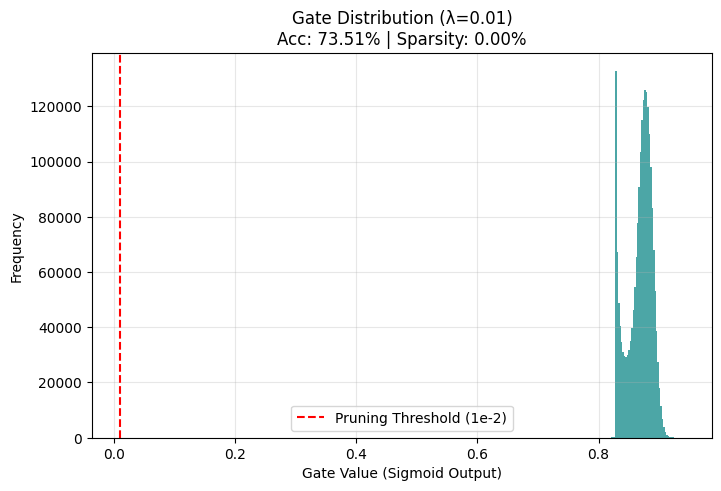


Lambda     | Accuracy     | Sparsity (%)
--------------------------------------------------
0.0001     | 75.11        | 11.78       
0.0001     | 74.06        | 34.71       
0.001      | 73.89        | 11.44       
0.001      | 74.28        | 35.68       
0.01       | 74.43        | 26.24       
0.01       | 74.03        | 58.03       
0.0001     | 74.13        | 0.00        
0.0001     | 75.21        | 0.00        
0.001      | 73.85        | 0.00        
0.001      | 74.76        | 0.00        
0.01       | 74.86        | 0.00        
0.01       | 74.62        | 0.00        
0.0001     | 73.53        | 0.00        
0.0001     | 74.36        | 0.00        
0.001      | 74.27        | 0.00        
0.001      | 74.09        | 0.00        
0.01       | 74.15        | 0.00        
0.01       | 73.51        | 0.00        


In [67]:
# =========================================================
# Step 10: Hyperparameter Search and Plotting
# (Decoupled LR + Gradient Clipping + Layer-wise Metrics)
# =========================================================

import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------
# Hyperparameter search space
# ---------------------------------------------------------
learning_rates = [1e-3]
gate_lrs = [1e-1, 1e-2, 1e-3]         # Specialized High LR for gates [cite: 131]
gate_init_values = [2.0]  # Start near 1.0 (unpruned) for stability 
lambda_values = [1e-4, 1e-3, 1e-2] 
epochs_list = [5,10]

# Store results
experiment_results = []

# =========================================================
# Run Experiments
# =========================================================

for lr in learning_rates:
    for glr in gate_lrs:
        for gate_init in gate_init_values:
            for lambda_val in lambda_values:
                for epochs in epochs_list:

                    print("\n" + "=" * 70)
                    print(f"LR={lr} | GateLR={glr} | Init={gate_init} | λ={lambda_val} | Epochs={epochs}")
                    print("=" * 70)

                    # 1. Fresh model initialization [cite: 124]
                    model = PrunableNet().to(device)

                    # 2. Reset gate scores manually (both Conv and Linear)
                    for module in model.modules():
                        if isinstance(module, (PrunableLinear, PrunableConv2d)):
                            module.gate_scores.data.fill_(gate_init)

                    # 3. Decoupled Optimizer: Weight LR vs Gate LR [cite: 98]
                    gate_params = [p for n, p in model.named_parameters() if "gate_scores" in n]
                    other_params = [p for n, p in model.named_parameters() if "gate_scores" not in n]

                    optimizer = optim.Adam([
                        {'params': other_params, 'lr': lr},
                        {'params': gate_params, 'lr': glr}
                    ])

                    # 4. Training Loop [cite: 95]
                    model.train()
                    for epoch in range(epochs):
                        total_loss_epoch = 0.0
                        for inputs, targets in train_loader:
                            inputs, targets = inputs.to(device), targets.to(device)
                            optimizer.zero_grad()

                            outputs = model(inputs)
                            cls_loss = criterion(outputs, targets)
                            sparsity_loss = compute_sparsity_loss(model) # [cite: 89]

                            total_loss = cls_loss + (lambda_val * sparsity_loss) # [cite: 87]

                            total_loss.backward() # [cite: 82]
                            
                            # Gradient Clipping specifically for gate stability [cite: 41]
                            torch.nn.utils.clip_grad_norm_(gate_params, max_norm=1.0)
                            
                            optimizer.step()
                            total_loss_epoch += total_loss.item()

                        print(f"Epoch [{epoch + 1}/{epochs}] | Loss: {total_loss_epoch/len(train_loader):.2f}")

                    # 5. Final Evaluation [cite: 99]
                    accuracy = evaluate(model, test_loader, device)
                    
                    # Flatten all gates across ALL layers for metrics [cite: 88, 101]
                    all_gates_tensor = torch.cat([g.flatten() for g in model.get_all_gates()])
                    sparsity = (all_gates_tensor < 0.01).float().mean().item() * 100
                    all_gates_np = all_gates_tensor.detach().cpu().numpy()

                    print(f"\nFinal Accuracy : {accuracy:.2f}% | Final Sparsity : {sparsity:.2f}%")

                    # Save results for final report table [cite: 116]
                    experiment_results.append([lr, glr, lambda_val, accuracy, sparsity])

                    # 6. Gate Histogram Plot [cite: 117]
                    plt.figure(figsize=(8, 5))
                    plt.hist(all_gates_np, bins=100, color='teal', alpha=0.7)
                    
                    # 
                    
                    plt.axvline(x=0.01, color='red', linestyle='--', label="Pruning Threshold (1e-2)")
                    plt.title(f"Gate Distribution (λ={lambda_val})\nAcc: {accuracy:.2f}% | Sparsity: {sparsity:.2f}%")
                    plt.xlabel("Gate Value (Sigmoid Output)")
                    plt.ylabel("Frequency")
                    plt.legend()
                    plt.grid(alpha=0.3)
                    plt.show()

# Final Summary for Markdown Report [cite: 113]
print("\n" + "="*50)
print(f"{'Lambda':<10} | {'Accuracy':<12} | {'Sparsity (%)':<12}")
print("-" * 50)
for res in experiment_results:
    print(f"{res[2]:<10} | {res[3]:<12.2f} | {res[4]:<12.2f}")